# Vendor Performance — ML Models

Three models built on `vendor_sales_summary.csv`:

| # | Model | Type |
|---|-------|------|
| 1 | Predict Profit Margin | Regression |
| 2 | Classify Vendors as High / Medium / Low | Classification |
| 3 | Detect Risky Vendors | Anomaly Detection |

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBRegressor, XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 1. Load & Clean Data

In [2]:
df_raw = pd.read_csv('dataset/vendor_sales_summary.csv', sep=';')
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (10648, 18)


,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,36.99,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,28.99,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,24.99,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594


In [3]:
# ── Cleaning ────────────────────────────────────────────────────────────────
# 1. Drop rows with zero sales — vendor never actually sold anything;
#    these rows have no meaningful profit margin or turnover to learn from.
df = df_raw[df_raw['TotalSalesDollars'] > 0].copy()

# 2. Clip extreme ProfitMargin outliers (below -200) — these are statistical
#    artifacts from near-zero sales with heavy freight costs, confirmed in EDA.
df = df[df['ProfitMargin'] > -200].copy()

# 3. Clip StockTurnover upper extreme (above 99th pct) — a handful of
#    tiny-volume rows have impossibly high turnover ratios.
st_cap = df['StockTurnover'].quantile(0.99)
df['StockTurnover'] = df['StockTurnover'].clip(upper=st_cap)

# 4. Create OrderSize feature (replicating EDA logic)
df['OrderSize'] = pd.qcut(
    df['TotalPurchaseQuantity'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'X-Large']
)

# 5. Derived ratio features — useful signals for all three models
df['PriceMarkup']     = (df['ActualPrice'] - df['PurchasePrice']) / df['PurchasePrice']
df['FreightPerUnit']  = df['TotalFreightCost']  / df['TotalPurchaseQuantity'].clip(lower=1)
df['TaxPerUnit']      = df['TotalExciseTax']    / df['TotalSalesQuantity'].clip(lower=1)

print(f"Clean shape: {df.shape}")
df[['ProfitMargin', 'StockTurnover', 'GrossProfit']].describe().round(2)

Clean shape: (10019, 22)


,ProfitMargin,StockTurnover,GrossProfit
count,10019.00,10019.00,10019.00
mean,25.58,1.54,13099.08
std,41.54,2.43,47564.32
min,-198.54,0.20,-38161.69
25%,19.57,0.87,122.64
50%,31.44,0.99,1812.02
75%,40.97,1.06,9701.44
max,99.72,18.96,1290667.91


## 2. Feature Matrix

Columns used as model inputs — text IDs (`VendorName`, `Description`) are dropped; `OrderSize` is ordinal-encoded.

In [4]:
FEATURE_COLS = [
    'PurchasePrice', 'Volume', 'ActualPrice',
    'TotalPurchaseQuantity', 'TotalPurchaseDollars',
    'TotalSalesQuantity',   'TotalSalesDollars',
    'TotalSalesPrice',      'TotalExciseTax',
    'TotalFreightCost',     'GrossProfit',
    'SalestoPurchaseRatio',
    'PriceMarkup', 'FreightPerUnit', 'TaxPerUnit',
    'OrderSize'   # ordinal encoded below
]

order_map = {'Small': 0, 'Medium': 1, 'Large': 2, 'X-Large': 3}
df['OrderSize'] = df['OrderSize'].map(order_map).astype(float)

X = df[FEATURE_COLS].copy()
cat_cols = X.select_dtypes(include='category').columns.tolist()
if cat_cols:
    X[cat_cols] = X[cat_cols].astype(float)
print("Feature matrix shape:", X.shape)
X.head(3)

Feature matrix shape: (10019, 16)


,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,SalestoPurchaseRatio,PriceMarkup,FreightPerUnit,TaxPerUnit,OrderSize
0,26.27,1750.0,36.99,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,1.338647,0.408070,0.472854,1.837389,3.0
1,23.19,1750.0,28.99,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,1.266830,0.250108,0.883510,1.837405,3.0
2,18.24,1750.0,24.99,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,1.327594,0.370066,0.660489,1.837416,3.0


---
## Model 1 — Predict Profit Margin (Regression)

> **Goal:** Given all features of a new vendor-brand row, predict its `ProfitMargin` (%).

Two models compared: Random Forest and XGBoost.

In [5]:
TARGET_REG = 'ProfitMargin'
y_reg = df[TARGET_REG]

# GrossProfit is a direct component of ProfitMargin — drop it for a realistic
# prediction scenario where margin is unknown for a new vendor.
X_reg = X.drop(columns=['GrossProfit', 'SalestoPurchaseRatio'])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train_r.shape} | Test: {X_test_r.shape}")

Train: (8015, 14) | Test: (2004, 14)


In [6]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
rf_preds = rf_reg.predict(X_test_r)

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    random_state=RANDOM_STATE, verbosity=0
)
xgb_reg.fit(X_train_r, y_train_r)
xgb_preds = xgb_reg.predict(X_test_r)

# ── Metrics ──────────────────────────────────────────────────────────────────
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:25s} | MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print(f"{'Model':25s} | MAE       RMSE      R²")
print('-' * 55)
rf_metrics  = reg_metrics('Random Forest',  y_test_r, rf_preds)
xgb_metrics = reg_metrics('XGBoost',        y_test_r, xgb_preds)

Model                     | MAE       RMSE      R²
-------------------------------------------------------
Random Forest             | MAE=4.95  RMSE=8.63  R²=0.9527
XGBoost                   | MAE=4.10  RMSE=6.82  R²=0.9705


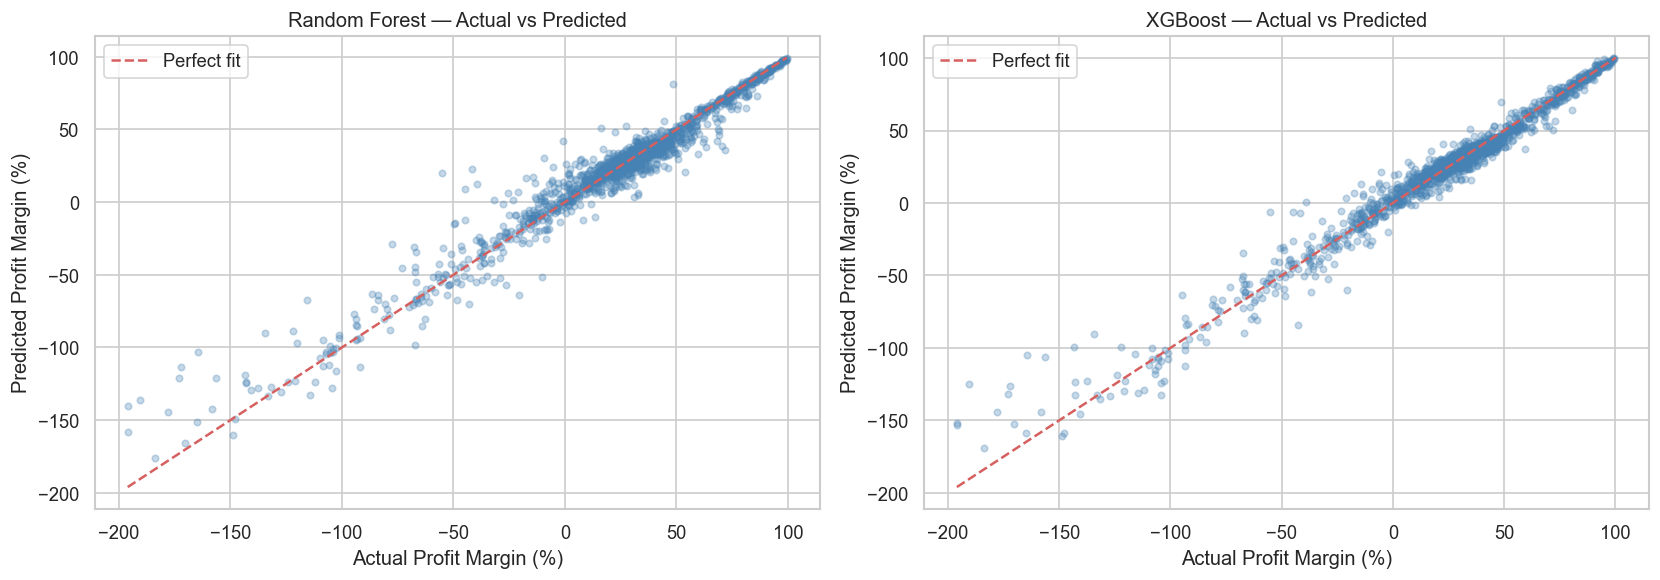

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [('Random Forest', rf_preds), ('XGBoost', xgb_preds)]):
    ax.scatter(y_test_r, preds, alpha=0.3, s=15, color='steelblue')
    lims = [min(y_test_r.min(), preds.min()), max(y_test_r.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Profit Margin (%)')
    ax.set_ylabel('Predicted Profit Margin (%)')
    ax.set_title(f'{name} — Actual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.show()

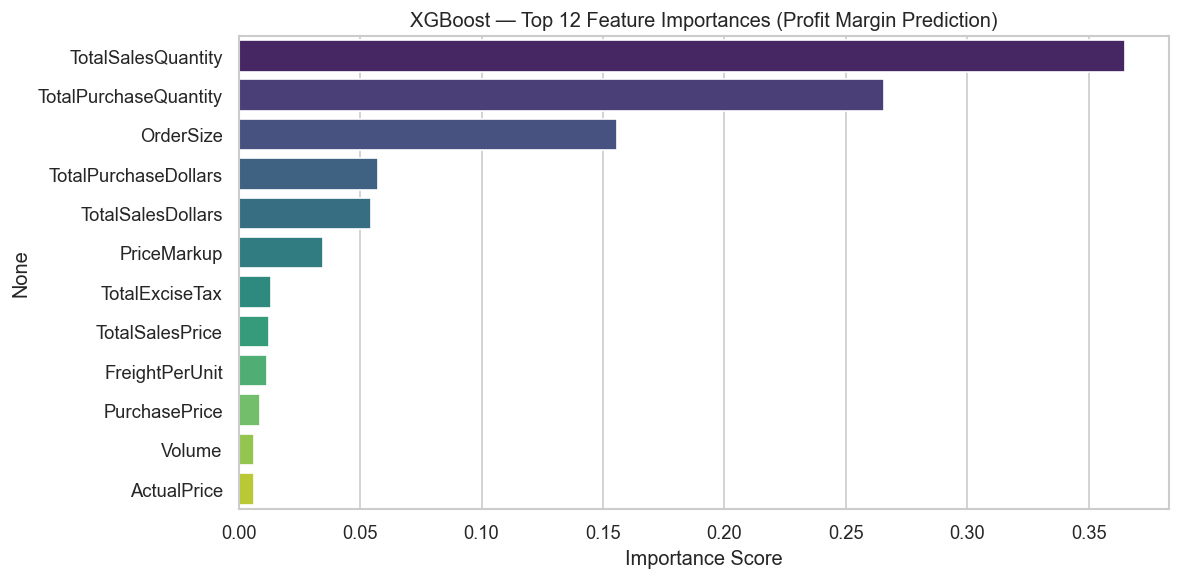

In [8]:
# Feature importance — XGBoost (best model)
feat_imp = pd.Series(
    xgb_reg.feature_importances_,
    index=X_reg.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values[:12], y=feat_imp.index[:12], palette='viridis')
plt.title('XGBoost — Top 12 Feature Importances (Profit Margin Prediction)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Model 2 — Vendor Performance Classification (High / Medium / Low)

> **Goal:** Label each vendor-brand as a **High**, **Medium**, or **Low** performer based on `ProfitMargin` and `StockTurnover`, then train a classifier so future vendors can be labelled automatically.

### Label Construction

Consistent with the EDA quantile approach, we build a composite score:

```
score = normalised(ProfitMargin) + normalised(StockTurnover)
```

| Label | Score range |
|-------|-------------|
| **High**   | top 33 % |
| **Medium** | middle 34 % |
| **Low**    | bottom 33 % |

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler_label = MinMaxScaler()
scores = scaler_label.fit_transform(df[['ProfitMargin', 'StockTurnover']])
df['CompositeScore'] = scores[:, 0] + scores[:, 1]   # sum of two normalised dims

df['PerformanceCategory'] = pd.qcut(
    df['CompositeScore'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(df['PerformanceCategory'].value_counts())

# Quick sanity check — median ProfitMargin per class should be monotonic
print()
print(df.groupby('PerformanceCategory', observed=True)[['ProfitMargin', 'StockTurnover']].median().round(2))

PerformanceCategory
Low       3340
High      3340
Medium    3339
Name: count, dtype: int64

                     ProfitMargin  StockTurnover
PerformanceCategory                             
Low                          5.45           0.75
Medium                      31.44           0.99
High                        51.92           1.35


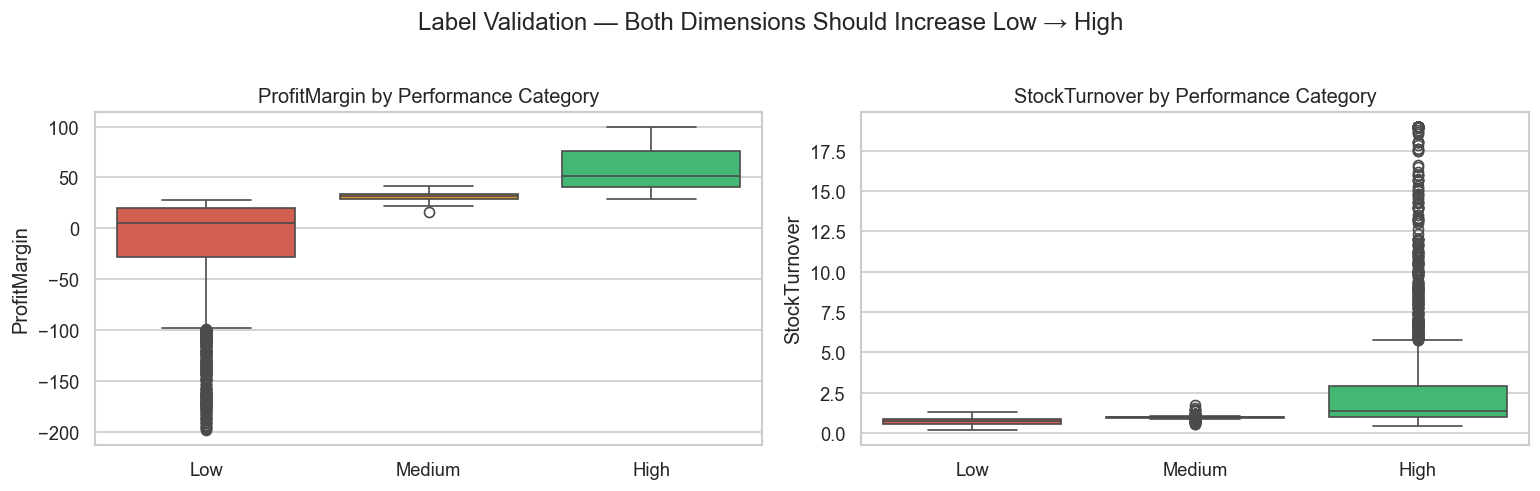

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['ProfitMargin', 'StockTurnover']):
    sns.boxplot(
        data=df, x='PerformanceCategory', y=col,
        order=['Low', 'Medium', 'High'],
        palette=['#e74c3c', '#f39c12', '#2ecc71'],
        ax=ax
    )
    ax.set_title(f'{col} by Performance Category')
    ax.set_xlabel('')

plt.suptitle('Label Validation — Both Dimensions Should Increase Low → High', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ── Prepare classification data ───────────────────────────────────────────────
TARGET_CLF = 'PerformanceCategory'

le = LabelEncoder()
y_clf = le.fit_transform(df[TARGET_CLF])   # Low=1, Medium=2, High=0 (alphabetical)

# Drop margin & turnover from features — they were used to BUILD the label;
# keeping them would cause data leakage.
X_clf = X.drop(columns=['GrossProfit'])   # GrossProfit also highly correlated

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)
print(f"Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print("Classes:", le.classes_)

Train: (8015, 15) | Test: (2004, 15)
Classes: ['High' 'Low' 'Medium']


In [12]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
rf_clf_preds = rf_clf.predict(X_test_c)

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_STATE, verbosity=0
)
xgb_clf.fit(X_train_c, y_train_c)
xgb_clf_preds = xgb_clf.predict(X_test_c)

# ── Reports ──────────────────────────────────────────────────────────────────
for name, preds in [('Random Forest', rf_clf_preds), ('XGBoost', xgb_clf_preds)]:
    print(f"\n{'='*45}")
    print(f" {name}")
    print('='*45)
    print(classification_report(y_test_c, preds, target_names=le.classes_))


 Random Forest
              precision    recall  f1-score   support

        High       0.98      0.98      0.98       668
         Low       0.99      0.99      0.99       668
      Medium       0.97      0.97      0.97       668

    accuracy                           0.98      2004
   macro avg       0.98      0.98      0.98      2004
weighted avg       0.98      0.98      0.98      2004


 XGBoost
              precision    recall  f1-score   support

        High       0.98      0.97      0.98       668
         Low       0.99      0.99      0.99       668
      Medium       0.97      0.97      0.97       668

    accuracy                           0.98      2004
   macro avg       0.98      0.98      0.98      2004
weighted avg       0.98      0.98      0.98      2004



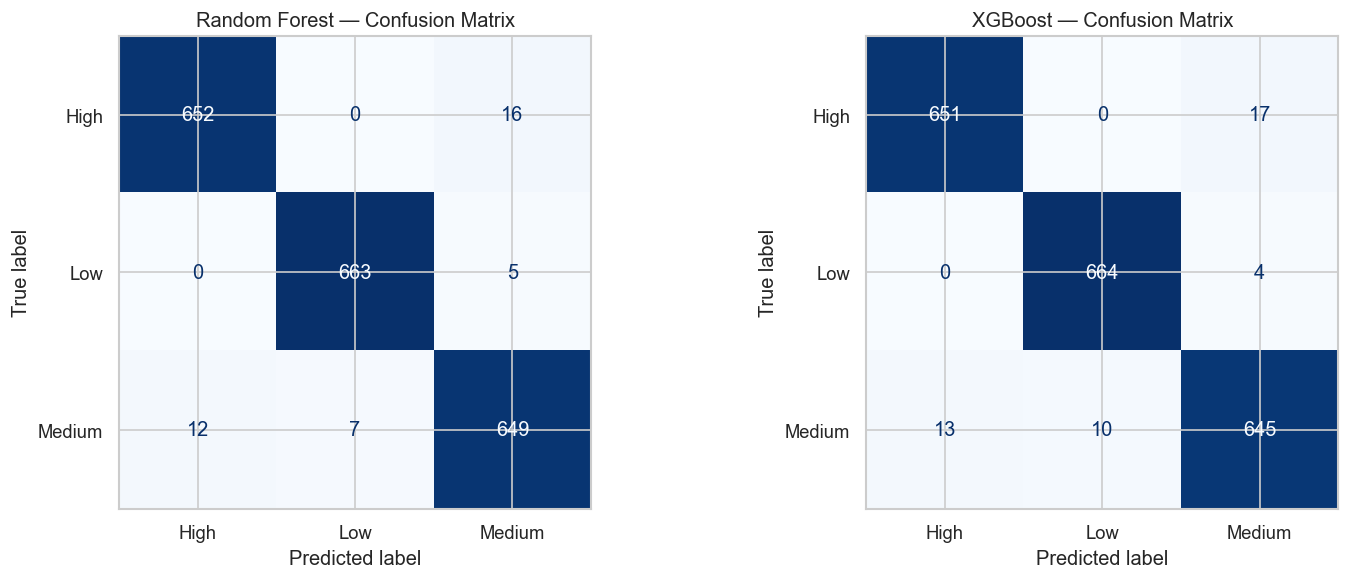

In [13]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, preds) in zip(
    axes,
    [('Random Forest', rf_clf_preds), ('XGBoost', xgb_clf_preds)]
):
    cm = confusion_matrix(y_test_c, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')

plt.tight_layout()
plt.show()

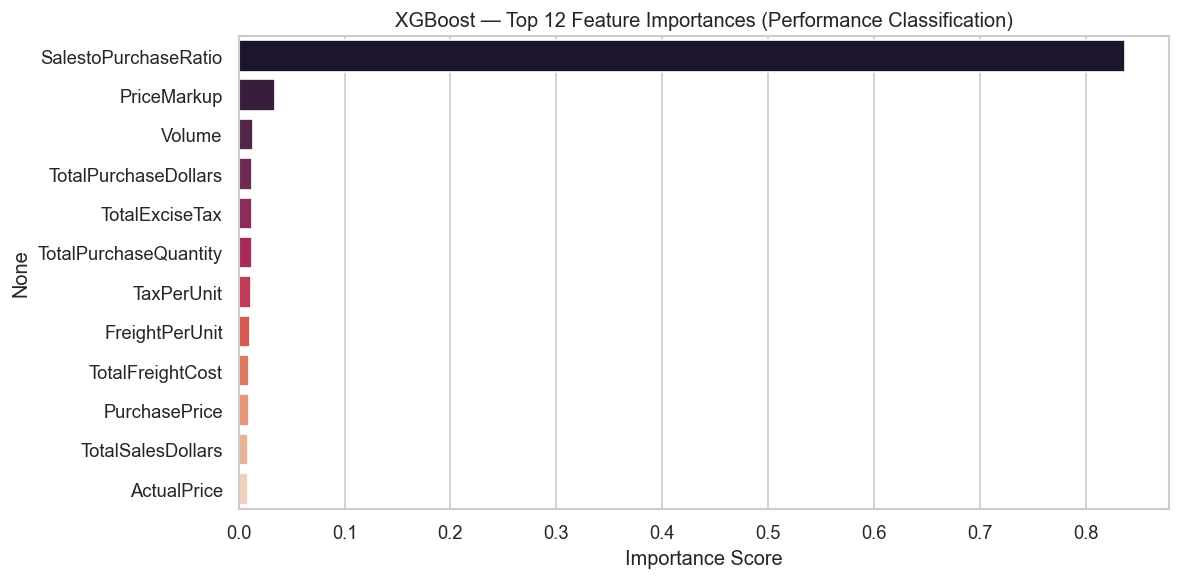

In [14]:
# Feature importance — XGBoost classifier
feat_imp_clf = pd.Series(
    xgb_clf.feature_importances_,
    index=X_clf.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_clf.values[:12], y=feat_imp_clf.index[:12], palette='rocket')
plt.title('XGBoost — Top 12 Feature Importances (Performance Classification)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Model 3 — Risky Vendor Detection (Anomaly Detection)

> **Goal:** Identify vendors operating in a "danger zone" — **low profit margin AND low stock turnover** simultaneously. Two approaches:
>
> - **Rule-based flag** (transparent, business-readable)
> - **Isolation Forest** (statistical anomaly detection, catches subtler patterns)

### 3a. Rule-Based Risk Flag

In [15]:
# Thresholds: consistent with the EDA quantile approach
pm_low_thresh  = df['ProfitMargin'].quantile(0.25)   # bottom 25% margin
st_low_thresh  = df['StockTurnover'].quantile(0.25)  # bottom 25% turnover

print(f"ProfitMargin  low threshold  (25th pct): {pm_low_thresh:.2f}%")
print(f"StockTurnover low threshold  (25th pct): {st_low_thresh:.4f}")

df['RiskFlag_Rule'] = (
    (df['ProfitMargin']  < pm_low_thresh) &
    (df['StockTurnover'] < st_low_thresh)
).astype(int)

n_risky_rule = df['RiskFlag_Rule'].sum()
print(f"\nVendors flagged as RISKY (rule-based): {n_risky_rule} "
      f"({n_risky_rule/len(df)*100:.1f}% of dataset)")

ProfitMargin  low threshold  (25th pct): 19.57%
StockTurnover low threshold  (25th pct): 0.8651

Vendors flagged as RISKY (rule-based): 2174 (21.7% of dataset)


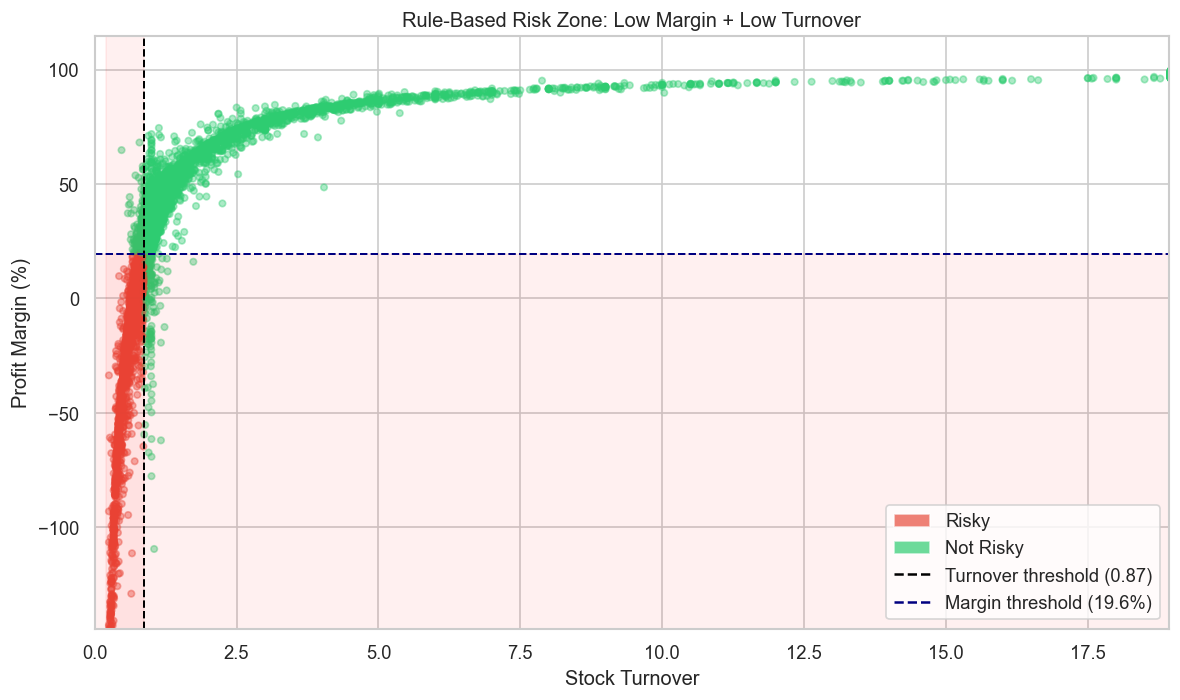

In [16]:
plt.figure(figsize=(10, 6))

colors = df['RiskFlag_Rule'].map({0: '#2ecc71', 1: '#e74c3c'})

plt.scatter(
    df['StockTurnover'], df['ProfitMargin'],
    c=colors, alpha=0.4, s=15
)

plt.axvline(st_low_thresh, color='black', linestyle='--', lw=1.2, label=f'Turnover threshold ({st_low_thresh:.2f})')
plt.axhline(pm_low_thresh, color='navy',  linestyle='--', lw=1.2, label=f'Margin threshold ({pm_low_thresh:.1f}%)')

# Shade the risk zone
plt.axvspan(df['StockTurnover'].min(), st_low_thresh, alpha=0.06, color='red')
plt.axhspan(df['ProfitMargin'].min(),  pm_low_thresh,  alpha=0.06, color='red')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.7, label='Risky'),
    Patch(facecolor='#2ecc71', alpha=0.7, label='Not Risky'),
]
plt.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='black', linestyle='--', label=f'Turnover threshold ({st_low_thresh:.2f})'),
    plt.Line2D([0], [0], color='navy',  linestyle='--', label=f'Margin threshold ({pm_low_thresh:.1f}%)')
])

plt.xlabel('Stock Turnover')
plt.ylabel('Profit Margin (%)')
plt.title('Rule-Based Risk Zone: Low Margin + Low Turnover')
plt.xlim(left=0, right=df['StockTurnover'].quantile(0.99))
plt.ylim(bottom=df['ProfitMargin'].quantile(0.01))
plt.tight_layout()
plt.show()

### 3b. Isolation Forest — Statistical Anomaly Detection

In [17]:
# Features for anomaly detection — focus on the financial health signals
ANOMALY_FEATURES = [
    'ProfitMargin', 'StockTurnover',
    'GrossProfit',  'SalestoPurchaseRatio',
    'TotalSalesDollars', 'TotalPurchaseDollars',
    'FreightPerUnit', 'TaxPerUnit', 'PriceMarkup'
]

X_anomaly = df[ANOMALY_FEATURES].copy()

scaler_anomaly = StandardScaler()
X_anomaly_scaled = scaler_anomaly.fit_transform(X_anomaly)

# contamination = expected fraction of true anomalies in the dataset.
# Set to roughly what the rule-based approach found (≈ bottom 5–10%).
iso = IsolationForest(
    n_estimators=200,
    contamination=0.07,
    random_state=RANDOM_STATE
)
iso.fit(X_anomaly_scaled)

# -1 = anomaly, +1 = normal  →  remap to 1/0
df['RiskFlag_IsoForest'] = (iso.predict(X_anomaly_scaled) == -1).astype(int)
df['AnomalyScore']       = -iso.decision_function(X_anomaly_scaled)  # higher = more anomalous

n_risky_iso = df['RiskFlag_IsoForest'].sum()
print(f"Vendors flagged RISKY (Isolation Forest): {n_risky_iso} "
      f"({n_risky_iso/len(df)*100:.1f}% of dataset)")

Vendors flagged RISKY (Isolation Forest): 702 (7.0% of dataset)


In [18]:
# Agreement between methods
both_risky   = ((df['RiskFlag_Rule'] == 1) & (df['RiskFlag_IsoForest'] == 1)).sum()
only_rule    = ((df['RiskFlag_Rule'] == 1) & (df['RiskFlag_IsoForest'] == 0)).sum()
only_iso     = ((df['RiskFlag_Rule'] == 0) & (df['RiskFlag_IsoForest'] == 1)).sum()

print(f"Both methods flag as risky : {both_risky}")
print(f"Only rule-based            : {only_rule}  (obvious low margin + low turnover)")
print(f"Only Isolation Forest      : {only_iso}  (subtler anomalies IsoForest caught)")

Both methods flag as risky : 38
Only rule-based            : 2136  (obvious low margin + low turnover)
Only Isolation Forest      : 664  (subtler anomalies IsoForest caught)


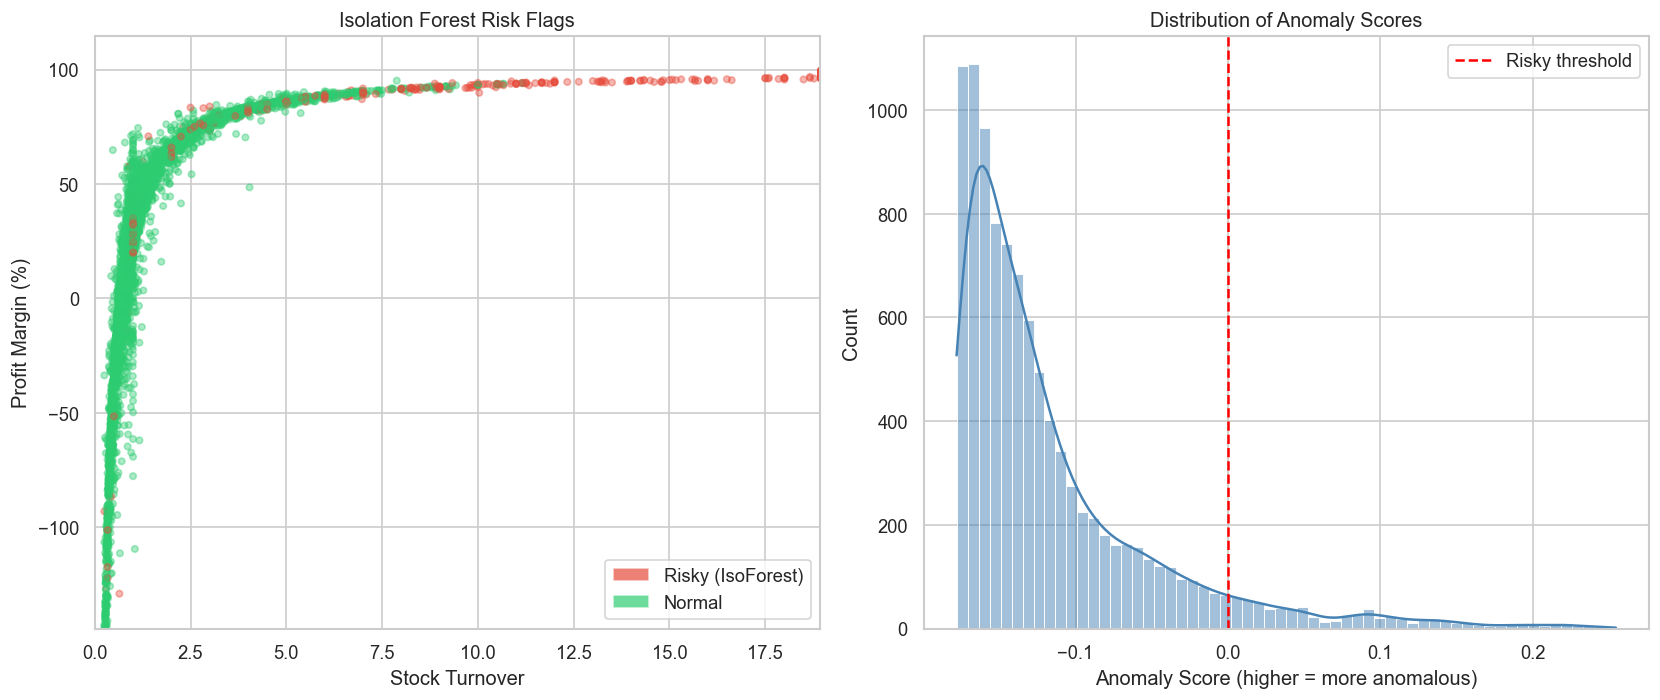

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Isolation Forest flags
ax = axes[0]
colors_iso = df['RiskFlag_IsoForest'].map({0: '#2ecc71', 1: '#e74c3c'})
ax.scatter(df['StockTurnover'], df['ProfitMargin'], c=colors_iso, alpha=0.4, s=15)
ax.set_xlim(left=0, right=df['StockTurnover'].quantile(0.99))
ax.set_ylim(bottom=df['ProfitMargin'].quantile(0.01))
ax.set_xlabel('Stock Turnover')
ax.set_ylabel('Profit Margin (%)')
ax.set_title('Isolation Forest Risk Flags')
legend_els = [
    Patch(facecolor='#e74c3c', alpha=0.7, label='Risky (IsoForest)'),
    Patch(facecolor='#2ecc71', alpha=0.7, label='Normal'),
]
ax.legend(handles=legend_els)

# Right — Anomaly score distribution
ax2 = axes[1]
threshold_score = df[df['RiskFlag_IsoForest'] == 1]['AnomalyScore'].min()
sns.histplot(df['AnomalyScore'], bins=60, color='steelblue', ax=ax2, kde=True)
ax2.axvline(threshold_score, color='red', linestyle='--', label=f'Risky threshold')
ax2.set_xlabel('Anomaly Score (higher = more anomalous)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Anomaly Scores')
ax2.legend()

plt.tight_layout()
plt.show()

In [20]:
# Final risk table — top 20 riskiest vendors by anomaly score
risk_cols = [
    'VendorName', 'Description',
    'ProfitMargin', 'StockTurnover', 'GrossProfit',
    'TotalSalesDollars', 'AnomalyScore',
    'RiskFlag_Rule', 'RiskFlag_IsoForest'
]

risky_vendors = (
    df[df['RiskFlag_IsoForest'] == 1][risk_cols]
    .sort_values('AnomalyScore', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

risky_vendors.style \
    .background_gradient(subset=['AnomalyScore'], cmap='Reds') \
    .format({'ProfitMargin': '{:.2f}%', 'StockTurnover': '{:.3f}',
             'GrossProfit': '${:,.0f}', 'TotalSalesDollars': '${:,.0f}',
             'AnomalyScore': '{:.4f}'})

,VendorName,Description,ProfitMargin,StockTurnover,GrossProfit,TotalSalesDollars,AnomalyScore,RiskFlag_Rule,RiskFlag_IsoForest
0,MARTIGNETTI COMPANIES,Tito's Handmade Vodka,21.06%,0.977,"$1,015,032","$4,819,073",0.2545,0,1
1,BROWN-FORMAN CORP,Jack Daniels No 7 Black,25.30%,0.979,"$1,290,668","$5,101,920",0.2498,0,1
2,DIAGEO NORTH AMERICA INC,Capt Morgan Spiced Rum,27.14%,0.994,"$1,214,775","$4,475,973",0.2483,0,1
3,PERNOD RICARD USA,Absolut 80 Proof,24.68%,0.999,"$1,119,817","$4,538,121",0.2478,0,1
4,DIAGEO NORTH AMERICA INC,Ketel One Vodka,28.41%,0.984,"$1,199,902","$4,223,108",0.2460,0,1
5,PERNOD RICARD USA,Jameson Irish Whiskey,21.49%,0.984,"$596,083","$2,773,368",0.2382,0,1
6,DIAGEO NORTH AMERICA INC,Smirnoff Traveler,19.43%,0.919,"$503,707","$2,592,041",0.2370,0,1
7,JIM BEAM BRANDS COMPANY,Skinnygirl Tangerine Vodka,99.54%,18.960,"$2,358","$2,368",0.2367,0,1
8,DIAGEO NORTH AMERICA INC,Tanqueray,27.90%,0.985,"$736,752","$2,640,491",0.2364,0,1
9,DIAGEO NORTH AMERICA INC,Baileys Irish Cream,32.49%,1.015,"$671,960","$2,068,091",0.2329,0,1


---
## Summary

| Model | Algorithm | Key Metric |
|-------|-----------|------------|
| Regression (Profit Margin) | XGBoost | R², RMSE, MAE |
| Classification (High/Med/Low) | XGBoost | Accuracy, F1 per class |
| Anomaly Detection (Risky) | Isolation Forest | Anomaly Score |

**Key decisions made:**
- Rows with zero sales dropped (no profit/turnover signal)
- Extreme ProfitMargin outliers (< −200) removed — confirmed data artifacts in EDA
- `GrossProfit` excluded from regression/classification features to prevent leakage
- `ProfitMargin` and `StockTurnover` excluded from classification feature matrix (they built the label)
- Performance labels built on a composite normalised score of both KPIs — consistent with EDA quantile approach
- Risky vendors = both rule-based (transparent) + Isolation Forest (catches subtler patterns)

In [21]:
# import joblib
# import os

# # Create folder if it doesn't exist
# os.makedirs("models", exist_ok=True)

# # Save regression models
# joblib.dump(rf_reg, "models/rf_reg.pkl")
# joblib.dump(xgb_reg, "models/xgb_reg.pkl")

# # Save classification models (if you trained them)
# joblib.dump(rf_clf, "models/rf_clf.pkl")
# joblib.dump(xgb_clf, "models/xgb_clf.pkl")

# # Save label encoder if classification uses one
# joblib.dump(le, "models/label_encoder.pkl")

# print("Models saved successfully")

In [22]:
"""
════════════════════════════════════════════════════════════════════════════════
  ADD THIS AS THE LAST CELL IN ML_Models.ipynb  (replace the commented block)
════════════════════════════════════════════════════════════════════════════════

This exports every artifact the Streamlit app needs to load instantly.
Run once after training; commit the /models/ folder with your app.
"""

import joblib
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── 0. Make sure OrderSize is numeric (qcut labels must be mapped first) ──────
# (Already done earlier in notebook — this is a safety check)
order_map = {'Small': 0, 'Medium': 1, 'Large': 2, 'X-Large': 3}
if df['OrderSize'].dtype == object or str(df['OrderSize'].dtype) == 'category':
    df['OrderSize'] = df['OrderSize'].map(order_map).astype(float)

# ── 1. Folder ──────────────────────────────────────────────────────────────────
os.makedirs("models", exist_ok=True)

# ── 2. Regression models + feature list ───────────────────────────────────────
REGRESSION_FEATURES = [
    "PurchasePrice", "Volume", "ActualPrice",
    "TotalPurchaseQuantity", "TotalPurchaseDollars",
    "TotalSalesQuantity", "TotalSalesDollars",
    "TotalSalesPrice", "TotalExciseTax", "TotalFreightCost",
    "PriceMarkup", "FreightPerUnit", "TaxPerUnit", "OrderSize",
]
joblib.dump(rf_reg,              "models/rf_reg.pkl")
joblib.dump(xgb_reg,             "models/xgb_reg.pkl")
joblib.dump(REGRESSION_FEATURES, "models/regression_features.pkl")

# ── 3. Test split for regression (for the metrics page) ───────────────────────
# Re-create the same split the notebook used so metrics are reproducible
from sklearn.model_selection import train_test_split
X_reg_full = df[REGRESSION_FEATURES].astype(float)
y_reg_full = df['ProfitMargin']
_, X_test_r, _, y_test_r = train_test_split(
    X_reg_full, y_reg_full, test_size=0.2, random_state=42
)
joblib.dump((X_test_r, y_test_r), "models/reg_test_split.pkl")

# ── 4. Classification models + label encoder + feature list ───────────────────
CLASSIFICATION_FEATURES = [
    "PurchasePrice", "Volume", "ActualPrice",
    "TotalPurchaseQuantity", "TotalPurchaseDollars",
    "TotalSalesQuantity", "TotalSalesDollars",
    "TotalSalesPrice", "TotalExciseTax", "TotalFreightCost",
    "SalestoPurchaseRatio",
    "PriceMarkup", "FreightPerUnit", "TaxPerUnit", "OrderSize",
]
joblib.dump(rf_clf,                  "models/rf_clf.pkl")
joblib.dump(xgb_clf,                 "models/xgb_clf.pkl")
joblib.dump(le,                      "models/label_encoder.pkl")
joblib.dump(CLASSIFICATION_FEATURES, "models/classification_features.pkl")

# ── 5. Test split for classification ──────────────────────────────────────────
X_clf_full = df[CLASSIFICATION_FEATURES].astype(float)
y_clf_full = le.transform(df['PerformanceCategory'])
_, X_test_c, _, y_test_c = train_test_split(
    X_clf_full, y_clf_full, test_size=0.2, stratify=y_clf_full, random_state=42
)
joblib.dump((X_test_c, y_test_c), "models/clf_test_split.pkl")

# ── 6. Anomaly detector (IsoForest + scaler + thresholds) ─────────────────────
ANOMALY_FEATURES = [
    "ProfitMargin", "StockTurnover",
    "GrossProfit", "SalestoPurchaseRatio",
    "TotalSalesDollars", "TotalPurchaseDollars",
    "FreightPerUnit", "TaxPerUnit", "PriceMarkup",
]
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

X_iso    = df[ANOMALY_FEATURES].fillna(0)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_iso)
iso      = IsolationForest(n_estimators=200, contamination=0.07, random_state=42)
iso.fit(X_scaled)

thresholds = {
    "pm": float(df['ProfitMargin'].quantile(0.25)),
    "st": float(df['StockTurnover'].quantile(0.25)),
}
joblib.dump(iso,              "models/iso_forest.pkl")
joblib.dump(scaler,           "models/iso_scaler.pkl")
joblib.dump(thresholds,       "models/iso_thresholds.pkl")
joblib.dump(ANOMALY_FEATURES, "models/anomaly_features.pkl")

# ── 7. Performance labeller scaler (so app recreates labels identically) ──────
scaler_label = MinMaxScaler()
scaler_label.fit(df[['ProfitMargin', 'StockTurnover']])
joblib.dump(scaler_label, "models/label_scaler.pkl")

# ── 8. Summary ────────────────────────────────────────────────────────────────
saved = os.listdir("models")
print(f"✅  Saved {len(saved)} files to /models/:\n")
for f in sorted(saved):
    path = f"models/{f}"
    size_kb = os.path.getsize(path) / 1024
    print(f"   {f:<35s}  {size_kb:>7.1f} KB")


✅  Saved 14 files to /models/:

   anomaly_features.pkl                     0.2 KB
   classification_features.pkl              0.3 KB
   clf_test_split.pkl                     267.7 KB
   iso_forest.pkl                        1371.1 KB
   iso_scaler.pkl                           1.2 KB
   iso_thresholds.pkl                       0.0 KB
   label_encoder.pkl                        0.5 KB
   label_scaler.pkl                         1.0 KB
   reg_test_split.pkl                     299.3 KB
   regression_features.pkl                  0.2 KB
   rf_clf.pkl                           13212.0 KB
   rf_reg.pkl                           142160.7 KB
   xgb_clf.pkl                           1847.2 KB
   xgb_reg.pkl                           1232.1 KB
